# ORACLE on a PyPSA toy example (2D, real weather profiles)

This version adds offshore wind, configurable snapshots, and real `p_max_pu` time series loaded from `model.energy`.

The ORACLE implementation is still **2D only**: choose any two exploratory variables, e.g. `("solar", "onwind")`, `("solar", "offwind")`, or `("onwind", "offwind")`.


In [ ]:
from __future__ import annotations

import itertools
import time
import warnings
from dataclasses import dataclass
from typing import Iterable, List, Tuple

import numpy as np
import pandas as pd
from scipy.optimize import linprog

try:
    from tqdm.auto import tqdm
except Exception:
    def tqdm(x, **kwargs):
        return x

try:
    import pypsa
except ImportError as exc:
    raise SystemExit("Install pypsa first: mamba install -c conda-forge pypsa highspy scipy matplotlib tqdm") from exc


def log(msg: str, verbose: bool = True):
    if verbose:
        print(msg, flush=True)


/home/julian-geis/mambaforge/envs/pypsa-oracle/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
TIME_SERIES_URL = "https://model.energy/data/time-series-f17c3736a2719ce7da58484180d89e2d.csv"


def _pick_column(df: pd.DataFrame, candidates: list[str], label: str) -> pd.Series | None:
    lower_map = {c.lower(): c for c in df.columns}
    for cand in candidates:
        if cand.lower() in lower_map:
            return df[lower_map[cand.lower()]].astype(float).clip(0, 1)
    print(f"Warning: no column found for {label}. Tried: {candidates}")
    return None


def synthetic_solar(index: pd.DatetimeIndex) -> pd.Series:
    hour = index.hour.to_numpy()
    values = np.maximum(0.0, np.sin((hour - 6) / 12 * np.pi))
    return pd.Series(values, index=index, name="solar")


def load_capacity_factors(
    start_date: str = "2011-03-01 00:00:00",
    end_date: str = "2011-03-07 23:00:00",
    url: str = TIME_SERIES_URL,
) -> pd.DataFrame:
    raw = pd.read_csv(url, index_col=0, parse_dates=True)
    raw = raw.loc[start_date:end_date]
    if raw.empty:
        raise ValueError("Selected time range is empty.")

    solar = _pick_column(raw, ["solar", "pv", "solar_pv", "solar-utility", "solar_rooftop"], "solar")
    onwind = _pick_column(raw, ["onwind", "onshore_wind", "wind_onshore", "wind"], "onwind")
    offwind = _pick_column(raw, ["offwind", "offwind-ac", "offwind-dc", "offshore_wind", "wind_offshore"], "offwind")

    if solar is None:
        solar = synthetic_solar(raw.index)
    if onwind is None:
        raise ValueError("Could not find an onwind column in the CSV.")
    if offwind is None:
        print("Using clipped 1.15 * onwind as fallback offshore wind profile.")
        offwind = (1.15 * onwind.rolling(3, min_periods=1, center=True).mean()).clip(0, 1)

    out = pd.DataFrame({"solar": solar, "onwind": onwind, "offwind": offwind}, index=raw.index)
    out = out.astype(float).clip(0, 1)
    return out


In [ ]:
Z_COMPONENTS = {
    "solar": ("Generator", "solar", "p_nom_opt"),
    "onwind": ("Generator", "onwind", "p_nom_opt"),
    "wind": ("Generator", "onwind", "p_nom_opt"),  # backwards-compatible alias
    "offwind": ("Generator", "offwind", "p_nom_opt"),
    "gas": ("Generator", "gas", "p_nom_opt"),
    "battery_energy": ("Store", "battery_store", "e_nom_opt"),
    "electrolysis": ("Link", "electrolyzer", "p_nom_opt"),
    "h2_store": ("Store", "h2_store", "e_nom_opt"),
    "h2_turbine": ("Link", "h2_turbine", "p_nom_opt"),
}


@dataclass
class OracleResult:
    z_points: np.ndarray
    outer_A: np.ndarray
    outer_b: np.ndarray
    history: pd.DataFrame
    v_star: float
    epsilon: float
    z_names: List[str]
    p_max_pu: pd.DataFrame
    solution_summary: pd.DataFrame


def build_toy_network(
    demand_gw: float = 100.0,
    p_max_pu: pd.DataFrame | None = None,
    start_date: str = "2011-03-01 00:00:00",
    end_date: str = "2011-03-07 23:00:00",
    time_series_url: str = TIME_SERIES_URL,
) -> pypsa.Network:
    if p_max_pu is None:
        p_max_pu = load_capacity_factors(start_date=start_date, end_date=end_date, url=time_series_url)
    else:
        p_max_pu = p_max_pu.copy()

    n = pypsa.Network()
    snapshots = pd.DatetimeIndex(p_max_pu.index)
    n.set_snapshots(snapshots)

    for carrier in ["electricity", "solar", "onwind", "offwind", "gas", "battery", "hydrogen"]:
        n.add("Carrier", carrier)

    n.add("Bus", "electricity", carrier="electricity")
    n.add("Bus", "battery", carrier="battery")
    n.add("Bus", "hydrogen", carrier="hydrogen")
    n.add("Load", "load", bus="electricity", p_set=demand_gw)

    n.add("Generator", "solar", bus="electricity", carrier="solar", p_nom_extendable=True,
          p_max_pu=p_max_pu["solar"], capital_cost=35.0, marginal_cost=0.0)
    n.add("Generator", "onwind", bus="electricity", carrier="onwind", p_nom_extendable=True,
          p_max_pu=p_max_pu["onwind"], capital_cost=50.0, marginal_cost=0.0)
    n.add("Generator", "offwind", bus="electricity", carrier="offwind", p_nom_extendable=True,
          p_max_pu=p_max_pu["offwind"], capital_cost=65.0, marginal_cost=0.0)
    n.add("Generator", "gas", bus="electricity", carrier="gas", p_nom_extendable=True,
          capital_cost=20.0, marginal_cost=90.0)

    n.add("Store", "battery_store", bus="battery", e_nom_extendable=True, e_cyclic=True, capital_cost=15.0)
    n.add("Link", "battery_charge", bus0="electricity", bus1="battery", p_nom_extendable=True, efficiency=0.95, capital_cost=8.0)
    n.add("Link", "battery_discharge", bus0="battery", bus1="electricity", p_nom_extendable=True, efficiency=0.95, capital_cost=8.0)

    n.add("Link", "electrolyzer", bus0="electricity", bus1="hydrogen", p_nom_extendable=True, efficiency=0.70, capital_cost=45.0)
    n.add("Store", "h2_store", bus="hydrogen", e_nom_extendable=True, e_cyclic=True, capital_cost=2.0)
    n.add("Link", "h2_turbine", bus0="hydrogen", bus1="electricity", p_nom_extendable=True, efficiency=0.50, capital_cost=35.0)
    return n


def get_objective_expr(model):
    return getattr(model.objective, "expression", model.objective)


def scalar_var(expr, name: str):
    return expr.sel({expr.dims[0]: name})


def z_expressions(n: pypsa.Network, z_names: Iterable[str]):
    m = n.model
    out = {}
    for z in z_names:
        component, asset, _ = Z_COMPONENTS[z]
        if component == "Generator":
            out[z] = scalar_var(m.variables["Generator-p_nom"], asset)
        elif component == "Link":
            out[z] = scalar_var(m.variables["Link-p_nom"], asset)
        elif component == "Store":
            out[z] = scalar_var(m.variables["Store-e_nom"], asset)
        else:
            raise ValueError(component)
    return out


def evaluate_z(n: pypsa.Network, z_names: Iterable[str]) -> np.ndarray:
    vals = []
    for z in z_names:
        component, asset, attr = Z_COMPONENTS[z]
        table = getattr(n, component.lower() + "s")
        vals.append(float(table.at[asset, attr]))
    return np.array(vals, dtype=float)

def evaluate_all_capacities(n: pypsa.Network) -> dict:
    """Collect installed capacities/energy capacities and objective from a solved network."""
    out = {"objective": float(n.objective)}
    for name, (component, asset, attr) in Z_COMPONENTS.items():
        if name == "wind":
            continue
        table = getattr(n, component.lower() + "s")
        out[name] = float(table.at[asset, attr])

    for link in ["battery_charge", "battery_discharge"]:
        out[link] = float(n.links.at[link, "p_nom_opt"])
    return out


def solution_record(n: pypsa.Network, z_names: Iterable[str], method: str, **meta) -> dict:
    """Store all capacities and cost for a solved ORACLE/VMM point."""
    rec = evaluate_all_capacities(n)
    z = evaluate_z(n, z_names)
    for name, value in zip(z_names, z):
        rec[name] = float(value)
    rec.update({"method": method, **meta})
    return rec


def solve_baseline(template: pypsa.Network, solver_name="highs", solver_options=None, verbose=True) -> Tuple[pypsa.Network, float]:
    t0 = time.perf_counter()
    n = template.copy()
    log("Solving baseline model...", verbose)
    n.optimize(solver_name=solver_name, solver_options=solver_options or {})
    log(f"Baseline solved in {time.perf_counter() - t0:.1f} s; objective={float(n.objective):,.2f}", verbose)
    return n, float(n.objective)


def solve_with_custom_objective(template, z_names, v_star, epsilon, objective_builder,
                                solver_name="highs", solver_options=None, verbose=False):
    n = template.copy()
    n.optimize.create_model()
    m = n.model
    original_objective = get_objective_expr(m)
    m.add_constraints(original_objective <= v_star * (1.0 + epsilon), name="oracle_budget")
    z_expr = z_expressions(n, z_names)
    objective = objective_builder(n, m, z_expr)
    m.add_objective(objective, overwrite=True)
    n.optimize.solve_model(solver_name=solver_name, solver_options=solver_options or {})
    return n


def vmm_initialization(template, z_names, v_star, epsilon, solver_name="highs", solver_options=None, verbose=True):
    points = []
    rows = []
    solution_rows = []
    log("Running VMM initialization...", verbose)
    t_all = time.perf_counter()
    tasks = [(name, "min") for name in z_names] + [(name, "max") for name in z_names]
    for name, sense in tqdm(tasks, desc="VMM", disable=not verbose):
        t0 = time.perf_counter()
        if sense == "min":
            obj = lambda n, m, z_expr, name=name: z_expr[name]
        else:
            obj = lambda n, m, z_expr, name=name: -z_expr[name]
        n_sol = solve_with_custom_objective(template, z_names, v_star, epsilon, obj, solver_name, solver_options)
        seconds = time.perf_counter() - t0
        z = evaluate_z(n_sol, z_names)
        points.append(z)
        rows.append({"variable": name, "sense": sense, "seconds": seconds, **dict(zip(z_names, z))})
        solution_rows.append(solution_record(n_sol, z_names, method="VMM", variable=name, sense=sense, seconds=seconds))
        log(f"  VMM {sense:3s} {name:10s}: {seconds:.1f} s, z={z}", verbose)
    Z = np.vstack(points)
    log(f"VMM finished in {time.perf_counter() - t_all:.1f} s", verbose)
    return Z, Z.min(axis=0), Z.max(axis=0), pd.DataFrame(rows), pd.DataFrame(solution_rows)


def halfspace_box(z_min: np.ndarray, z_max: np.ndarray):
    A = np.array([[1, 0], [-1, 0], [0, 1], [0, -1]], dtype=float)
    b = np.array([z_max[0], -z_min[0], z_max[1], -z_min[1]], dtype=float)
    return A, b


def polygon_vertices(A: np.ndarray, b: np.ndarray, tol=1e-7) -> np.ndarray:
    verts = []
    for i, j in itertools.combinations(range(len(b)), 2):
        M = np.vstack([A[i], A[j]])
        if abs(np.linalg.det(M)) < 1e-10:
            continue
        z = np.linalg.solve(M, np.array([b[i], b[j]]))
        if np.all(A @ z <= b + tol):
            verts.append(z)
    if not verts:
        raise RuntimeError("Outer polygon has no vertices; check bounds/cuts.")
    V = np.unique(np.round(np.vstack(verts), decimals=10), axis=0)
    center = V.mean(axis=0)
    angles = np.arctan2(V[:, 1] - center[1], V[:, 0] - center[0])
    return V[np.argsort(angles)]


def linf_distance_to_inner(z: np.ndarray, Z_points: np.ndarray) -> float:
    m, nz = Z_points.shape
    c = np.r_[np.zeros(m), 1.0]
    A_ub, b_ub = [], []
    for j in range(nz):
        A_ub.append(np.r_[Z_points[:, j], -1.0]); b_ub.append(z[j])
        A_ub.append(np.r_[-Z_points[:, j], -1.0]); b_ub.append(-z[j])
    A_eq = [np.r_[np.ones(m), 0.0]]
    b_eq = [1.0]
    bounds = [(0, None)] * m + [(0, None)]
    res = linprog(c, A_ub=np.array(A_ub), b_ub=np.array(b_ub),
                  A_eq=np.array(A_eq), b_eq=np.array(b_eq), bounds=bounds, method="highs")
    if not res.success:
        raise RuntimeError(res.message)
    return float(res.x[-1])


def farthest_trial_point_2d(A: np.ndarray, b: np.ndarray, Z_points: np.ndarray):
    verts = polygon_vertices(A, b)
    dists = np.array([linf_distance_to_inner(v, Z_points) for v in verts])
    idx = int(np.argmax(dists))
    return verts[idx], float(dists[idx]), verts


def solve_projection(template, z_names, z_trial, v_star, epsilon, solver_name="highs", solver_options=None, verbose=True):
    t0 = time.perf_counter()
    n = template.copy()
    n.optimize.create_model()
    m = n.model
    original_objective = get_objective_expr(m)
    m.add_constraints(original_objective <= v_star * (1.0 + epsilon), name="oracle_budget")
    z_expr = z_expressions(n, z_names)

    rho = m.add_variables(lower=0, name="oracle_rho")
    for j, name in enumerate(z_names):
        delta = m.add_variables(lower=-np.inf, name=f"oracle_delta_{name}")
        m.add_constraints(z_trial[j] - z_expr[name] == delta, name=f"oracle_delta_def_{name}")
        m.add_constraints(delta <= rho, name=f"oracle_delta_pos_{name}")
        m.add_constraints(-delta <= rho, name=f"oracle_delta_neg_{name}")

    m.add_objective(rho, overwrite=True)
    n.optimize.solve_model(solver_name=solver_name, solver_options=solver_options or {})

    z_feas = evaluate_z(n, z_names)
    distance = float(np.max(np.abs(z_trial - z_feas)))

    mu = []
    for name in z_names:
        try:
            dual = m.constraints[f"oracle_delta_def_{name}"].dual
            mu.append(float(dual.values))
        except Exception:
            mu = None
            break
    if mu is not None:
        mu = np.array(mu, dtype=float)
        if mu @ z_trial < mu @ z_feas:
            mu = -mu
        if mu @ z_trial <= mu @ z_feas + 1e-7:
            mu = None

    if mu is None:
        warnings.warn("Could not extract a strict dual cut; using heuristic cut normal.")
        mu = z_trial - z_feas
        if np.linalg.norm(mu) < 1e-9:
            mu = None

    log(f"  projection solved in {time.perf_counter() - t0:.1f} s; d_proj={distance:.4g}; z_feas={z_feas}", verbose)
    return n, z_feas, distance, mu


In [ ]:
def run_oracle_2d(
    epsilon=0.10,
    tol=0.5,
    max_iter=20,
    z_names=("solar", "onwind"),
    solver_name="highs",
    solver_options=None,
    demand_gw=100.0,
    p_max_pu: pd.DataFrame | None = None,
    start_date: str = "2011-03-01 00:00:00",
    end_date: str = "2011-03-07 23:00:00",
    time_series_url: str = TIME_SERIES_URL,
    verbose=True,
) -> OracleResult:
    z_names = list(z_names)
    if len(z_names) != 2:
        raise ValueError("This toy implementation supports exactly two exploratory variables.")

    t_total = time.perf_counter()
    if p_max_pu is None:
        p_max_pu = load_capacity_factors(start_date=start_date, end_date=end_date, url=time_series_url)
    template = build_toy_network(demand_gw=demand_gw, p_max_pu=p_max_pu)

    n_opt, v_star = solve_baseline(template, solver_name, solver_options, verbose)
    z_star = evaluate_z(n_opt, z_names)
    baseline_row = solution_record(n_opt, z_names, method="cost_optimum", variable="objective", sense="min", seconds=np.nan)
    log(f"Cost-optimal z={z_star}", verbose)

    Z_vmm, z_min, z_max, vmm_log, vmm_solutions = vmm_initialization(template, z_names, v_star, epsilon, solver_name, solver_options, verbose)
    Z_points = np.vstack([z_star, Z_vmm])
    solution_rows = [baseline_row] + vmm_solutions.to_dict("records")
    A, b = halfspace_box(z_min, z_max)

    rows = []
    iterator = tqdm(range(max_iter), desc="ORACLE", disable=not verbose)
    for k in iterator:
        t_iter = time.perf_counter()
        z_trial, d_oi, _ = farthest_trial_point_2d(A, b, Z_points)
        log(f"iter={k:02d} d_OI={d_oi:.4g} z_trial={z_trial} points={len(Z_points)} cuts={len(b)}", verbose)
        row = {"iteration": k, "d_oi": d_oi, "trial_0": z_trial[0], "trial_1": z_trial[1],
               "n_points_before": len(Z_points), "n_cuts_before": len(b)}
        if d_oi <= tol:
            row.update({"d_proj": np.nan, "seconds": time.perf_counter() - t_iter, "stopped": True})
            rows.append(row)
            break

        n_proj, z_feas, d_proj, mu = solve_projection(template, z_names, z_trial, v_star, epsilon, solver_name, solver_options, verbose)
        Z_points = np.vstack([Z_points, z_feas])
        solution_rows.append(solution_record(n_proj, z_names, method="ORACLE_projection", iteration=k, d_proj=d_proj, seconds=np.nan))

        added_cut = False
        if d_proj > 1e-5 and mu is not None:
            A = np.vstack([A, mu])
            b = np.r_[b, mu @ z_feas]
            added_cut = True

        row.update({"d_proj": d_proj, "z_feas_0": z_feas[0], "z_feas_1": z_feas[1],
                    "added_cut": added_cut, "seconds": time.perf_counter() - t_iter, "stopped": False})
        rows.append(row)

    hist = pd.DataFrame(rows)
    hist.attrs["vmm_log"] = vmm_log
    solution_summary = pd.DataFrame(solution_rows)
    solution_summary["cost_gap_percent"] = 100.0 * (solution_summary["objective"] / v_star - 1.0)
    log(f"ORACLE total runtime: {time.perf_counter() - t_total:.1f} s", verbose)
    return OracleResult(Z_points, A, b, hist, v_star, epsilon, z_names, p_max_pu, solution_summary)


def plot_result(res: OracleResult, path="oracle_toy_2d.png"):
    import matplotlib.pyplot as plt
    from scipy.spatial import ConvexHull

    V = polygon_vertices(res.outer_A, res.outer_b)
    fig, ax = plt.subplots(figsize=(7, 5))
    ax.fill(V[:, 0], V[:, 1], alpha=0.15, label="outer approximation O")
    ax.plot(np.r_[V[:, 0], V[0, 0]], np.r_[V[:, 1], V[0, 1]], label="outer boundary")
    ax.scatter(res.z_points[:, 0], res.z_points[:, 1], label="near-optimal points")

    if len(res.z_points) >= 3:
        hull = ConvexHull(res.z_points)
        H = res.z_points[hull.vertices]
        ax.fill(H[:, 0], H[:, 1], alpha=0.25, label="inner approximation I")

    ax.set_xlabel(f"{res.z_names[0]} capacity")
    ax.set_ylabel(f"{res.z_names[1]} capacity")
    ax.set_title(f"Toy ORACLE, epsilon={res.epsilon:.0%}")
    ax.legend()
    ax.grid(True, alpha=0.3)
    fig.tight_layout()
    fig.savefig(path, dpi=160)
    print(f"Saved {path}")


## 1. Configure snapshots and load real capacity factors

In [ ]:
start_date = "2011-03-01 00:00:00"
end_date = "2011-03-03 23:00:00"  # change this to extend/reduce the horizon

demand_gw = 100.0
solver_name = "highs"
solver_options = {"time_limit": 120}

p_max_pu_select = load_capacity_factors(start_date=start_date, end_date=end_date)
print(p_max_pu_select.head())
print("Snapshots:", len(p_max_pu_select), p_max_pu_select.index[0], "to", p_max_pu_select.index[-1])


Using clipped 1.15 * onwind as fallback offshore wind profile.
                     solar  onwind   offwind
time                                        
2011-03-01 00:00:00    0.0   0.112  0.146625
2011-03-01 01:00:00    0.0   0.143  0.165217
2011-03-01 02:00:00    0.0   0.176  0.205083
2011-03-01 03:00:00    0.0   0.216  0.248400
2011-03-01 04:00:00    0.0   0.256  0.284433
Snapshots: 72 2011-03-01 00:00:00 to 2011-03-03 23:00:00


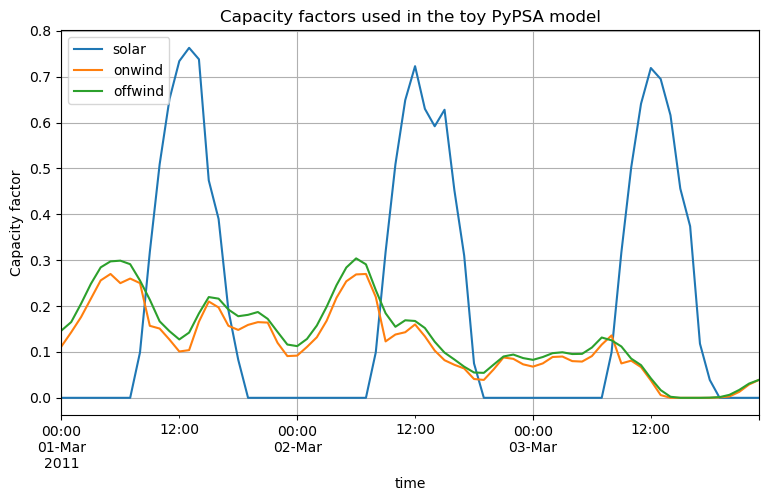

In [ ]:
import matplotlib.pyplot as plt

p_max_pu_select[["solar", "onwind", "offwind"]].plot(
    title="Capacity factors used in the toy PyPSA model",
    ylabel="Capacity factor",
    grid=True,
    figsize=(9, 5),
)
plt.show()


## 2. Smoke test: solve the default PyPSA model once

In [ ]:
template = build_toy_network(demand_gw=demand_gw, p_max_pu=p_max_pu_select)
n_base, v_star = solve_baseline(template, solver_name=solver_name, solver_options=solver_options, verbose=True)
print("z(solar, onwind, offwind) =", evaluate_z(n_base, ["solar", "onwind", "offwind"]))


Solving baseline model...


/tmp/ipykernel_28161/1688061066.py:130: FutureWarning: The default value of `include_objective_constant` will change from True to False in version 2.0. Set `include_objective_constant` explicitly to suppress this warning. Using False improves LP numerical conditioning by not including the objective constant as a variable.
  n.optimize(solver_name=solver_name, solver_options=solver_options or {})
INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.model:Solver options:
 - time_limit: 120
INFO:linopy.io: Writing time: 0.1s
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 874 primals, 1810 duals
Objective: 4.53e+04
Solver model: available
Solver message: Optimal

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-ext-p-lower, Generator-ext-p-upper, Link-ext-p-lower, Link-ext-p-upper, Store-ext-e-lower, Store-ext-e-upper, Store-energy_balance were not assigned to the network.


Running HiGHS 1.14.0 (git hash: n/a): Copyright (c) 2026 under MIT licence terms
LP linopy-problem-i2u4q916 has 1810 rows; 874 cols; 3563 nonzeros
Coefficient ranges:
  Matrix  [4e-04, 1e+00]
  Cost    [2e+00, 9e+01]
  Bound   [0e+00, 0e+00]
  RHS     [1e+02, 1e+02]
Presolving model
1033 rows, 827 cols, 2739 nonzeros 0s
889 rows, 683 cols, 2451 nonzeros 0s
Dependent equations search running on 216 equations with time limit of 1.20s
Dependent equations search removed 0 rows and 0 nonzeros in 0.00s (limit = 1.20s)
889 rows, 683 cols, 2451 nonzeros 0s
Presolve reductions: rows 889(-921); columns 683(-191); nonzeros 2451(-1112) 
Solving the presolved LP
Using dual simplex solver
  Iteration        Objective     Infeasibilities num(sum)
          0     0.0000000000e+00 Pr: 72(4800) 0.0s
        718     4.5253997086e+04 Pr: 0(0) 0.0s

Performed postsolve
Solving the original LP from the solution after postsolve

Model name          : linopy-problem-i2u4q916
Model status        : Optimal
Simp

## 3. VMM initialization only

Choose any two exploratory variables for the 2D ORACLE run.


In [ ]:
epsilon = 0.10
z_names = ["solar", "onwind"]  # try ["solar", "offwind"] or ["onwind", "offwind"]

Z_vmm, z_min, z_max, vmm_log, vmm_solutions = vmm_initialization(
    template, z_names, v_star, epsilon,
    solver_name=solver_name, solver_options=solver_options, verbose=True,
)

display(vmm_log)
display(vmm_solutions)
print("z_min:", z_min)
print("z_max:", z_max)


Running VMM initialization...


VMM:   0%|          | 0/4 [00:00<?, ?it/s]/tmp/ipykernel_28161/1688061066.py:138: FutureWarning: The default value of `include_objective_constant` will change from True to False in version 2.0. Set `include_objective_constant` explicitly to suppress this warning. Using False improves LP numerical conditioning by not including the objective constant as a variable.
  n.optimize.create_model()
INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.model:Solver options:
 - time_limit: 120
INFO:linopy.io: Writing time: 0.06s
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 874 primals, 1811 duals
Objective: 3.00e+02
Solver model: available
Solver message: Optimal

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-ext-p-lower, Generator-ext-p-upper, Link-ext-p-lower, Link-ext-p-upper, Store-ext-e-lower, Store-ext-e-upper, Store-energy_balance, oracle_budget were not assigned to the network.


Running HiGHS 1.14.0 (git hash: n/a): Copyright (c) 2026 under MIT licence terms
LP linopy-problem-573hq1ab has 1811 rows; 874 cols; 3645 nonzeros
Coefficient ranges:
  Matrix  [4e-04, 9e+01]
  Cost    [1e+00, 1e+00]
  Bound   [0e+00, 0e+00]
  RHS     [1e+02, 5e+04]
Presolving model
1034 rows, 827 cols, 2821 nonzeros 0s
890 rows, 683 cols, 2533 nonzeros 0s
Dependent equations search running on 216 equations with time limit of 1.20s
Dependent equations search removed 0 rows and 0 nonzeros in 0.00s (limit = 1.20s)
890 rows, 683 cols, 2533 nonzeros 0s
Presolve reductions: rows 890(-921); columns 683(-191); nonzeros 2533(-1112) 
Solving the presolved LP
Using dual simplex solver
  Iteration        Objective     Infeasibilities num(sum)
          0     0.0000000000e+00 Pr: 72(10600) 0.0s
        630     3.0039672306e+02 Pr: 0(0) 0.0s

Performed postsolve
Solving the original LP from the solution after postsolve

Model name          : linopy-problem-573hq1ab
Model status        : Optimal
Sim

VMM:  25%|██▌       | 1/4 [00:00<00:02,  1.26it/s]/tmp/ipykernel_28161/1688061066.py:138: FutureWarning: The default value of `include_objective_constant` will change from True to False in version 2.0. Set `include_objective_constant` explicitly to suppress this warning. Using False improves LP numerical conditioning by not including the objective constant as a variable.
  n.optimize.create_model()
INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.model:Solver options:
 - time_limit: 120
INFO:linopy.io: Writing time: 0.06s
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 874 primals, 1811 duals
Objective: 0.00e+00
Solver model: available
Solver message: Optimal

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-ext-p-lower, Generator-ext-p-upper, Link-ext-p-lower, Link-ext-p-upper, Store-ext-e-lower, Store-ext-e-upper, Store-energy_balance, oracle_budget were not assigned to the network.


Running HiGHS 1.14.0 (git hash: n/a): Copyright (c) 2026 under MIT licence terms
LP linopy-problem-hqgk_30z has 1811 rows; 874 cols; 3645 nonzeros
Coefficient ranges:
  Matrix  [4e-04, 9e+01]
  Cost    [1e+00, 1e+00]
  Bound   [0e+00, 0e+00]
  RHS     [1e+02, 5e+04]
Presolving model
1034 rows, 827 cols, 2821 nonzeros 0s
890 rows, 683 cols, 2533 nonzeros 0s
Dependent equations search running on 216 equations with time limit of 1.20s
Dependent equations search removed 0 rows and 0 nonzeros in 0.00s (limit = 1.20s)
890 rows, 683 cols, 2533 nonzeros 0s
Presolve reductions: rows 890(-921); columns 683(-191); nonzeros 2533(-1112) 
Solving the presolved LP
Using dual simplex solver
  Iteration        Objective     Infeasibilities num(sum)
          0     0.0000000000e+00 Pr: 72(10600) 0.0s
        555     0.0000000000e+00 Pr: 0(0) 0.0s

Performed postsolve
Solving the original LP from the solution after postsolve

Model name          : linopy-problem-hqgk_30z
Model status        : Optimal
Sim

...

VMM: 100%|██████████| 4/4 [00:02<00:00,  1.43it/s]

VMM finished in 2.8 s


,variable,sense,seconds,solar,onwind
0,solar,min,0.790082,300.396723,440.635802
1,onwind,min,0.660704,409.263117,-0.000000
2,solar,max,0.672493,714.986997,-0.000000
3,onwind,max,0.658401,322.050824,460.999469


,objective,solar,onwind,offwind,gas,battery_energy,electrolysis,h2_store,h2_turbine,battery_charge,battery_discharge,method,variable,sense,seconds
0,300.396723,300.396723,440.635802,-0.000000,-0.0,826.908499,24.447347,619.209379,18.999399,133.521046,94.799647,VMM,solar,min,0.790082
1,0.000000,409.263117,-0.000000,241.082853,-0.0,1153.977590,-0.000000,-0.000000,-0.000000,204.518257,104.874042,VMM,onwind,min,0.660704
2,-714.986997,714.986997,-0.000000,-0.000000,-0.0,1450.239194,3.927434,78.472188,4.904512,206.727738,105.263158,VMM,solar,max,0.672493
3,-460.999469,322.050824,460.999469,-0.000000,-0.0,667.465665,25.075339,649.841204,35.102625,137.321542,86.302829,VMM,onwind,max,0.658401


z_min: [300.39672306  -0.        ]
z_max: [714.98699691 460.99946906]


## 4. Short ORACLE run

In [ ]:
result = run_oracle_2d(
    epsilon=0.10,
    tol=1.0,
    max_iter=5,
    z_names=z_names,
    solver_name=solver_name,
    solver_options=solver_options,
    demand_gw=demand_gw,
    p_max_pu=p_max_pu_select,
    verbose=True,
)

result.history


Solving baseline model...


/tmp/ipykernel_28161/1688061066.py:130: FutureWarning: The default value of `include_objective_constant` will change from True to False in version 2.0. Set `include_objective_constant` explicitly to suppress this warning. Using False improves LP numerical conditioning by not including the objective constant as a variable.
  n.optimize(solver_name=solver_name, solver_options=solver_options or {})
INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.model:Solver options:
 - time_limit: 120
INFO:linopy.io: Writing time: 0.06s
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 874 primals, 1810 duals
Objective: 4.53e+04
Solver model: available
Solver message: Optimal

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-ext-p-lower, Generator-ext-p-upper, Link-ext-p-lower, Link-ext-p-upper, Store-ext-e-lower, Store-ext-e-upper, Store-energy_balance were not assigned to the network.


Running HiGHS 1.14.0 (git hash: n/a): Copyright (c) 2026 under MIT licence terms
LP linopy-problem-4k4f8j3k has 1810 rows; 874 cols; 3563 nonzeros
Coefficient ranges:
  Matrix  [4e-04, 1e+00]
  Cost    [2e+00, 9e+01]
  Bound   [0e+00, 0e+00]
  RHS     [1e+02, 1e+02]
Presolving model
1033 rows, 827 cols, 2739 nonzeros 0s
889 rows, 683 cols, 2451 nonzeros 0s
Dependent equations search running on 216 equations with time limit of 1.20s
Dependent equations search removed 0 rows and 0 nonzeros in 0.00s (limit = 1.20s)
889 rows, 683 cols, 2451 nonzeros 0s
Presolve reductions: rows 889(-921); columns 683(-191); nonzeros 2451(-1112) 
Solving the presolved LP
Using dual simplex solver
  Iteration        Objective     Infeasibilities num(sum)
          0     0.0000000000e+00 Pr: 72(4800) 0.0s
        718     4.5253997086e+04 Pr: 0(0) 0.0s

Performed postsolve
Solving the original LP from the solution after postsolve

Model name          : linopy-problem-4k4f8j3k
Model status        : Optimal
Simp

VMM:   0%|          | 0/4 [00:00<?, ?it/s]/tmp/ipykernel_28161/1688061066.py:138: FutureWarning: The default value of `include_objective_constant` will change from True to False in version 2.0. Set `include_objective_constant` explicitly to suppress this warning. Using False improves LP numerical conditioning by not including the objective constant as a variable.
  n.optimize.create_model()
INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.model:Solver options:
 - time_limit: 120
INFO:linopy.io: Writing time: 0.05s
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 874 primals, 1811 duals
Objective: 3.00e+02
Solver model: available
Solver message: Optimal

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-ext-p-lower, Generator-ext-p-upper, Link-ext-p-lower, Link-ext-p-upper, Store-ext-e-lower, Store-ext-e-upper, Store-energy_balance, oracle_budget were not assigned to the network.


Running HiGHS 1.14.0 (git hash: n/a): Copyright (c) 2026 under MIT licence terms
LP linopy-problem-tlsgj_0l has 1811 rows; 874 cols; 3645 nonzeros
Coefficient ranges:
  Matrix  [4e-04, 9e+01]
  Cost    [1e+00, 1e+00]
  Bound   [0e+00, 0e+00]
  RHS     [1e+02, 5e+04]
Presolving model
1034 rows, 827 cols, 2821 nonzeros 0s
890 rows, 683 cols, 2533 nonzeros 0s
Dependent equations search running on 216 equations with time limit of 1.20s
Dependent equations search removed 0 rows and 0 nonzeros in 0.00s (limit = 1.20s)
890 rows, 683 cols, 2533 nonzeros 0s
Presolve reductions: rows 890(-921); columns 683(-191); nonzeros 2533(-1112) 
Solving the presolved LP
Using dual simplex solver
  Iteration        Objective     Infeasibilities num(sum)
          0     0.0000000000e+00 Pr: 72(10600) 0.0s
        630     3.0039672306e+02 Pr: 0(0) 0.0s

Performed postsolve
Solving the original LP from the solution after postsolve

Model name          : linopy-problem-tlsgj_0l
Model status        : Optimal
Sim

...

/tmp/ipykernel_28161/1688061066.py:224: FutureWarning: The default value of `include_objective_constant` will change from True to False in version 2.0. Set `include_objective_constant` explicitly to suppress this warning. Using False improves LP numerical conditioning by not including the objective constant as a variable.
  n.optimize.create_model()
INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.model:Solver options:
 - time_limit: 120
INFO:linopy.io: Writing time: 0.08s
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 877 primals, 1817 duals
Objective: 1.01e+01
Solver model: available
Solver message: Optimal

INFO:pypsa.optimization.optimize:The variable 'oracle_rho' could not be mapped to the network component because it does not include the symbol '-'.
INFO:pypsa.optimization.optimize:The variable 'oracle_delta_solar' could not be mapped to the network component because it does not include the symbol '-'.
INFO:pyps

Running HiGHS 1.14.0 (git hash: n/a): Copyright (c) 2026 under MIT licence terms
LP linopy-problem-8cqw8tid has 1817 rows; 877 cols; 3657 nonzeros
Coefficient ranges:
  Matrix  [4e-04, 9e+01]
  Cost    [1e+00, 1e+00]
  Bound   [0e+00, 0e+00]
  RHS     [1e+02, 5e+04]
Presolving model
1038 rows, 828 cols, 2829 nonzeros 0s
894 rows, 684 cols, 2541 nonzeros 0s
Dependent equations search running on 216 equations with time limit of 1.20s
Dependent equations search removed 0 rows and 0 nonzeros in 0.00s (limit = 1.20s)
894 rows, 684 cols, 2541 nonzeros 0s
Presolve reductions: rows 894(-923); columns 684(-193); nonzeros 2541(-1116) 
Solving the presolved LP
Using dual simplex solver
  Iteration        Objective     Infeasibilities num(sum)
          0     0.0000000000e+00 Pr: 74(10890.2) 0.0s
        612     1.0050361526e+01 Pr: 0(0) 0.0s

Performed postsolve
Solving the original LP from the solution after postsolve

Model name          : linopy-problem-8cqw8tid
Model status        : Optimal
S

ORACLE: 100%|██████████| 5/5 [00:04<00:00,  1.22it/s]

ORACLE total runtime: 8.4 s


,iteration,d_oi,trial_0,trial_1,n_points_before,n_cuts_before,d_proj,z_feas_0,z_feas_1,added_cut,seconds,stopped
0,0,212.127657,714.986997,460.999469,5,4,199.263599,515.723398,261.735870,True,0.746777,False
1,1,87.297979,300.396723,-0.000000,6,5,56.806553,357.203276,56.806553,True,0.757490,False
2,2,20.963631,369.087559,-0.000000,7,6,0.000000,369.087559,-0.000000,False,0.796247,False
3,3,14.477077,300.396723,328.340335,8,6,10.788580,311.185303,339.128915,True,1.076585,False
4,4,14.093163,349.841719,460.999469,9,7,10.050362,339.791357,450.949108,True,0.733894,False


Saved /home/julian-geis/Documents/06_PhD/03RobustModelling/ORACLE/oracle_toy_2d.png


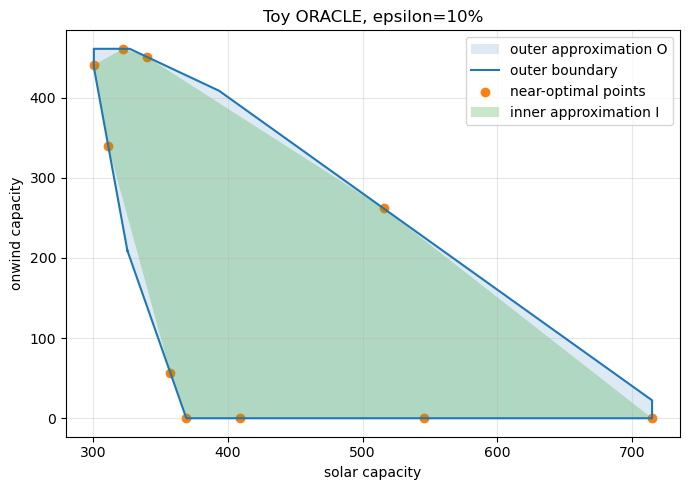

In [ ]:
plot_result(result, path="/home/julian-geis/Documents/06_PhD/03RobustModelling/ORACLE/oracle_toy_2d.png")


In [ ]:
pd.DataFrame(result.z_points, columns=result.z_names)

,solar,onwind
0,545.875165,-0.000000
1,300.396723,440.635802
2,409.263117,-0.000000
3,714.986997,-0.000000
4,322.050824,460.999469
5,515.723398,261.735870
6,357.203276,56.806553
7,369.087559,-0.000000
8,311.185303,339.128915
9,339.791357,450.949108


## 5. Technology-capacity and cost diagnostics

This now uses the capacities and costs saved during the original baseline, VMM, and ORACLE projection solves. No re-optimization is done for these plots.

Re-optimization is only needed for new sampled/interpolated points that were not actually solved by PyPSA.


In [ ]:
def analyze_oracle_points(result: OracleResult, verbose=True) -> pd.DataFrame:
    """Return cached capacities/costs from solved baseline, VMM, and ORACLE projection points."""
    df = result.solution_summary.copy()
    # Keep one row per solved point/method; do not re-optimize.
    if verbose:
        print(f"Loaded {len(df)} cached solved points; no PyPSA re-optimization performed.")
    return df


def plot_capacity_and_cost_maps(df: pd.DataFrame, z_names: list[str], path="/mnt/data/oracle_tech_cost_maps.png"):
    """Scatter maps: x/y are explored capacities, color shows other capacities or cost."""
    import math
    import matplotlib.pyplot as plt

    x, y = z_names
    value_cols = [
        c for c in [
            "offwind", "gas", "battery_energy", "battery_charge", "battery_discharge",
            "electrolysis", "h2_store", "h2_turbine", "objective", "cost_gap_percent"
        ]
        if c in df.columns and c not in z_names
    ]

    ncols = 2
    nrows = math.ceil(len(value_cols) / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(6.5 * ncols, 4.8 * nrows), squeeze=False)

    for ax, col in zip(axes.ravel(), value_cols):
        sc = ax.scatter(df[x], df[y], c=df[col], s=90)
        ax.set_xlabel(f"{x} capacity [GW]")
        ax.set_ylabel(f"{y} capacity [GW]")
        ax.set_title(col)
        ax.grid(True, alpha=0.3)
        fig.colorbar(sc, ax=ax, label=col)

    for ax in axes.ravel()[len(value_cols):]:
        ax.axis("off")

    fig.tight_layout()
    fig.savefig(path, dpi=160)
    print(f"Saved {path}")
    return fig


### Run post-processing plots


In [ ]:
tech_df = analyze_oracle_points(result, verbose=True)
tech_df


Loaded 10 cached solved points; no PyPSA re-optimization performed.


,objective,solar,onwind,offwind,gas,battery_energy,electrolysis,h2_store,h2_turbine,battery_charge,battery_discharge,method,variable,sense,seconds,iteration,d_proj,cost_gap_percent
0,45253.997086,545.875165,-0.000000,-0.000000,-0.0,1509.816837,2.245018,51.859924,3.241245,290.239225,107.626335,cost_optimum,objective,min,NaN,NaN,NaN,0.000000
1,300.396723,300.396723,440.635802,-0.000000,-0.0,826.908499,24.447347,619.209379,18.999399,133.521046,94.799647,VMM,solar,min,0.694111,NaN,NaN,-99.336198
2,0.000000,409.263117,-0.000000,241.082853,-0.0,1153.977590,-0.000000,-0.000000,-0.000000,204.518257,104.874042,VMM,onwind,min,0.693623,NaN,NaN,-100.000000
3,-714.986997,714.986997,-0.000000,-0.000000,-0.0,1450.239194,3.927434,78.472188,4.904512,206.727738,105.263158,VMM,solar,max,0.726509,NaN,NaN,-101.579942
4,-460.999469,322.050824,460.999469,-0.000000,-0.0,667.465665,25.075339,649.841204,35.102625,137.321542,86.302829,VMM,onwind,max,0.959321,NaN,NaN,-101.018693
5,199.263599,515.723398,261.735870,-0.000000,-0.0,976.795748,13.157193,330.168587,22.011239,151.302541,94.640448,ORACLE_projection,NaN,NaN,NaN,0.0,199.263599,-99.559677
6,56.806553,357.203276,56.806553,236.666150,-0.0,977.179215,18.878968,443.157596,15.234532,169.057949,96.803199,ORACLE_projection,NaN,NaN,NaN,1.0,56.806553,-99.874472
7,0.000000,369.087559,-0.000000,266.882191,-0.0,1012.219077,17.939045,417.735841,14.143710,176.729792,97.388343,ORACLE_projection,NaN,NaN,NaN,2.0,0.000000,-100.000000
8,10.788580,311.185303,339.128915,64.513017,-0.0,871.691623,22.680600,558.579388,16.428806,147.588563,96.155314,ORACLE_projection,NaN,NaN,NaN,3.0,10.788580,-99.976160
9,10.050362,339.791357,450.949108,-0.000000,-0.0,674.155503,23.939083,615.514325,35.549526,123.220629,86.078198,ORACLE_projection,NaN,NaN,NaN,4.0,10.050362,-99.977791


Saved /home/julian-geis/Documents/06_PhD/03RobustModelling/ORACLE/oracle_tech_cost_maps.png


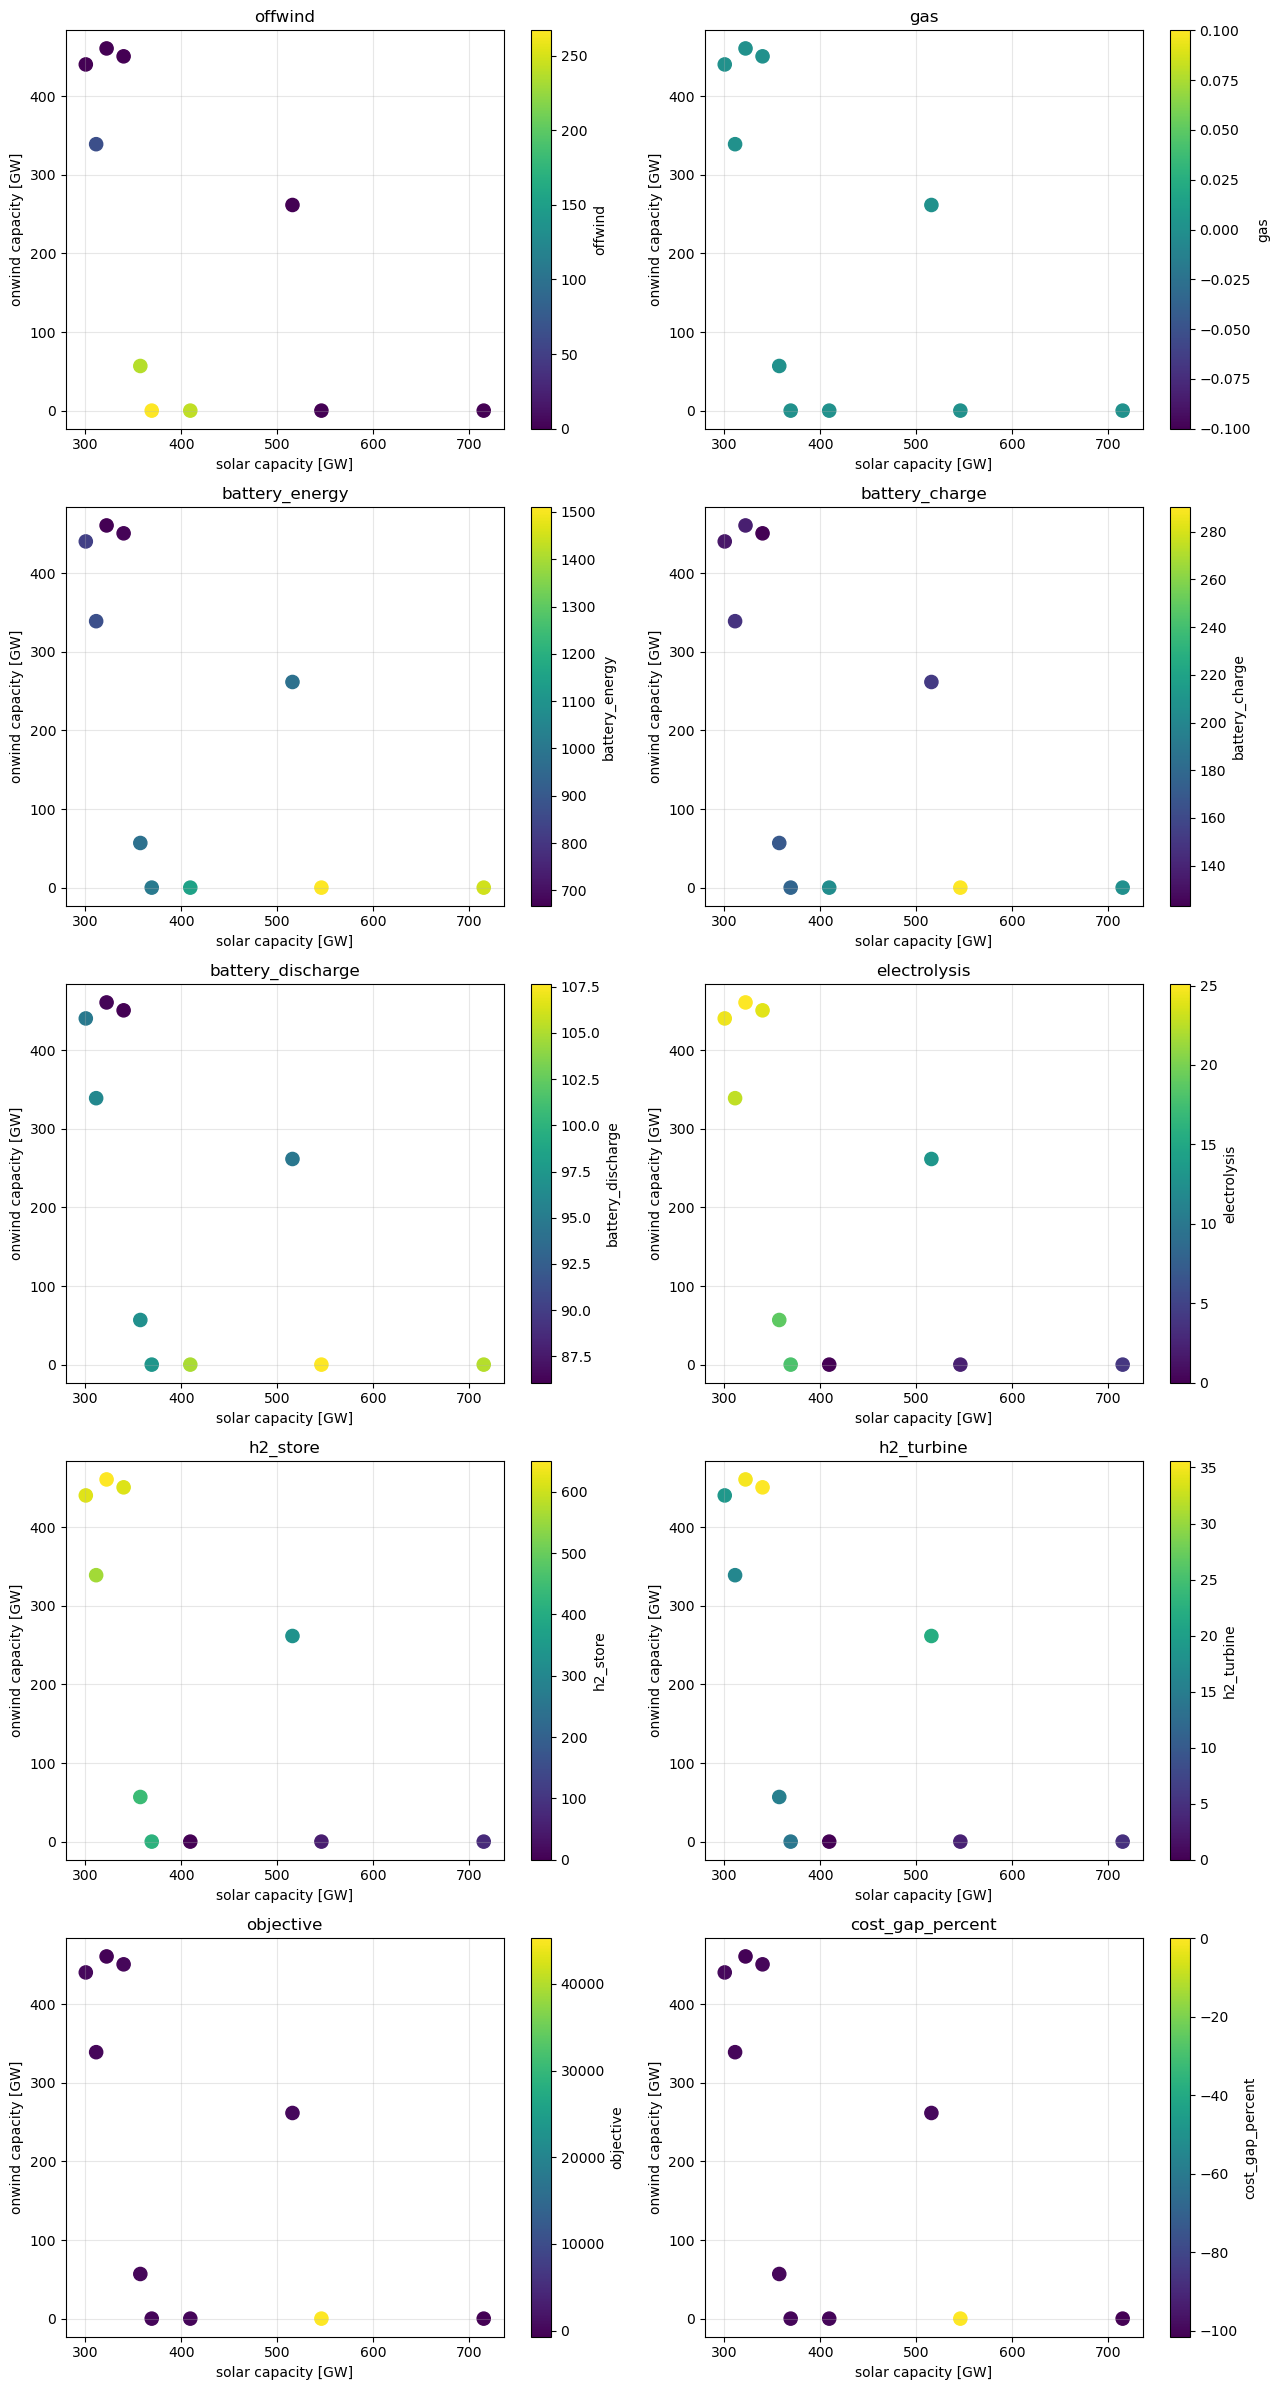

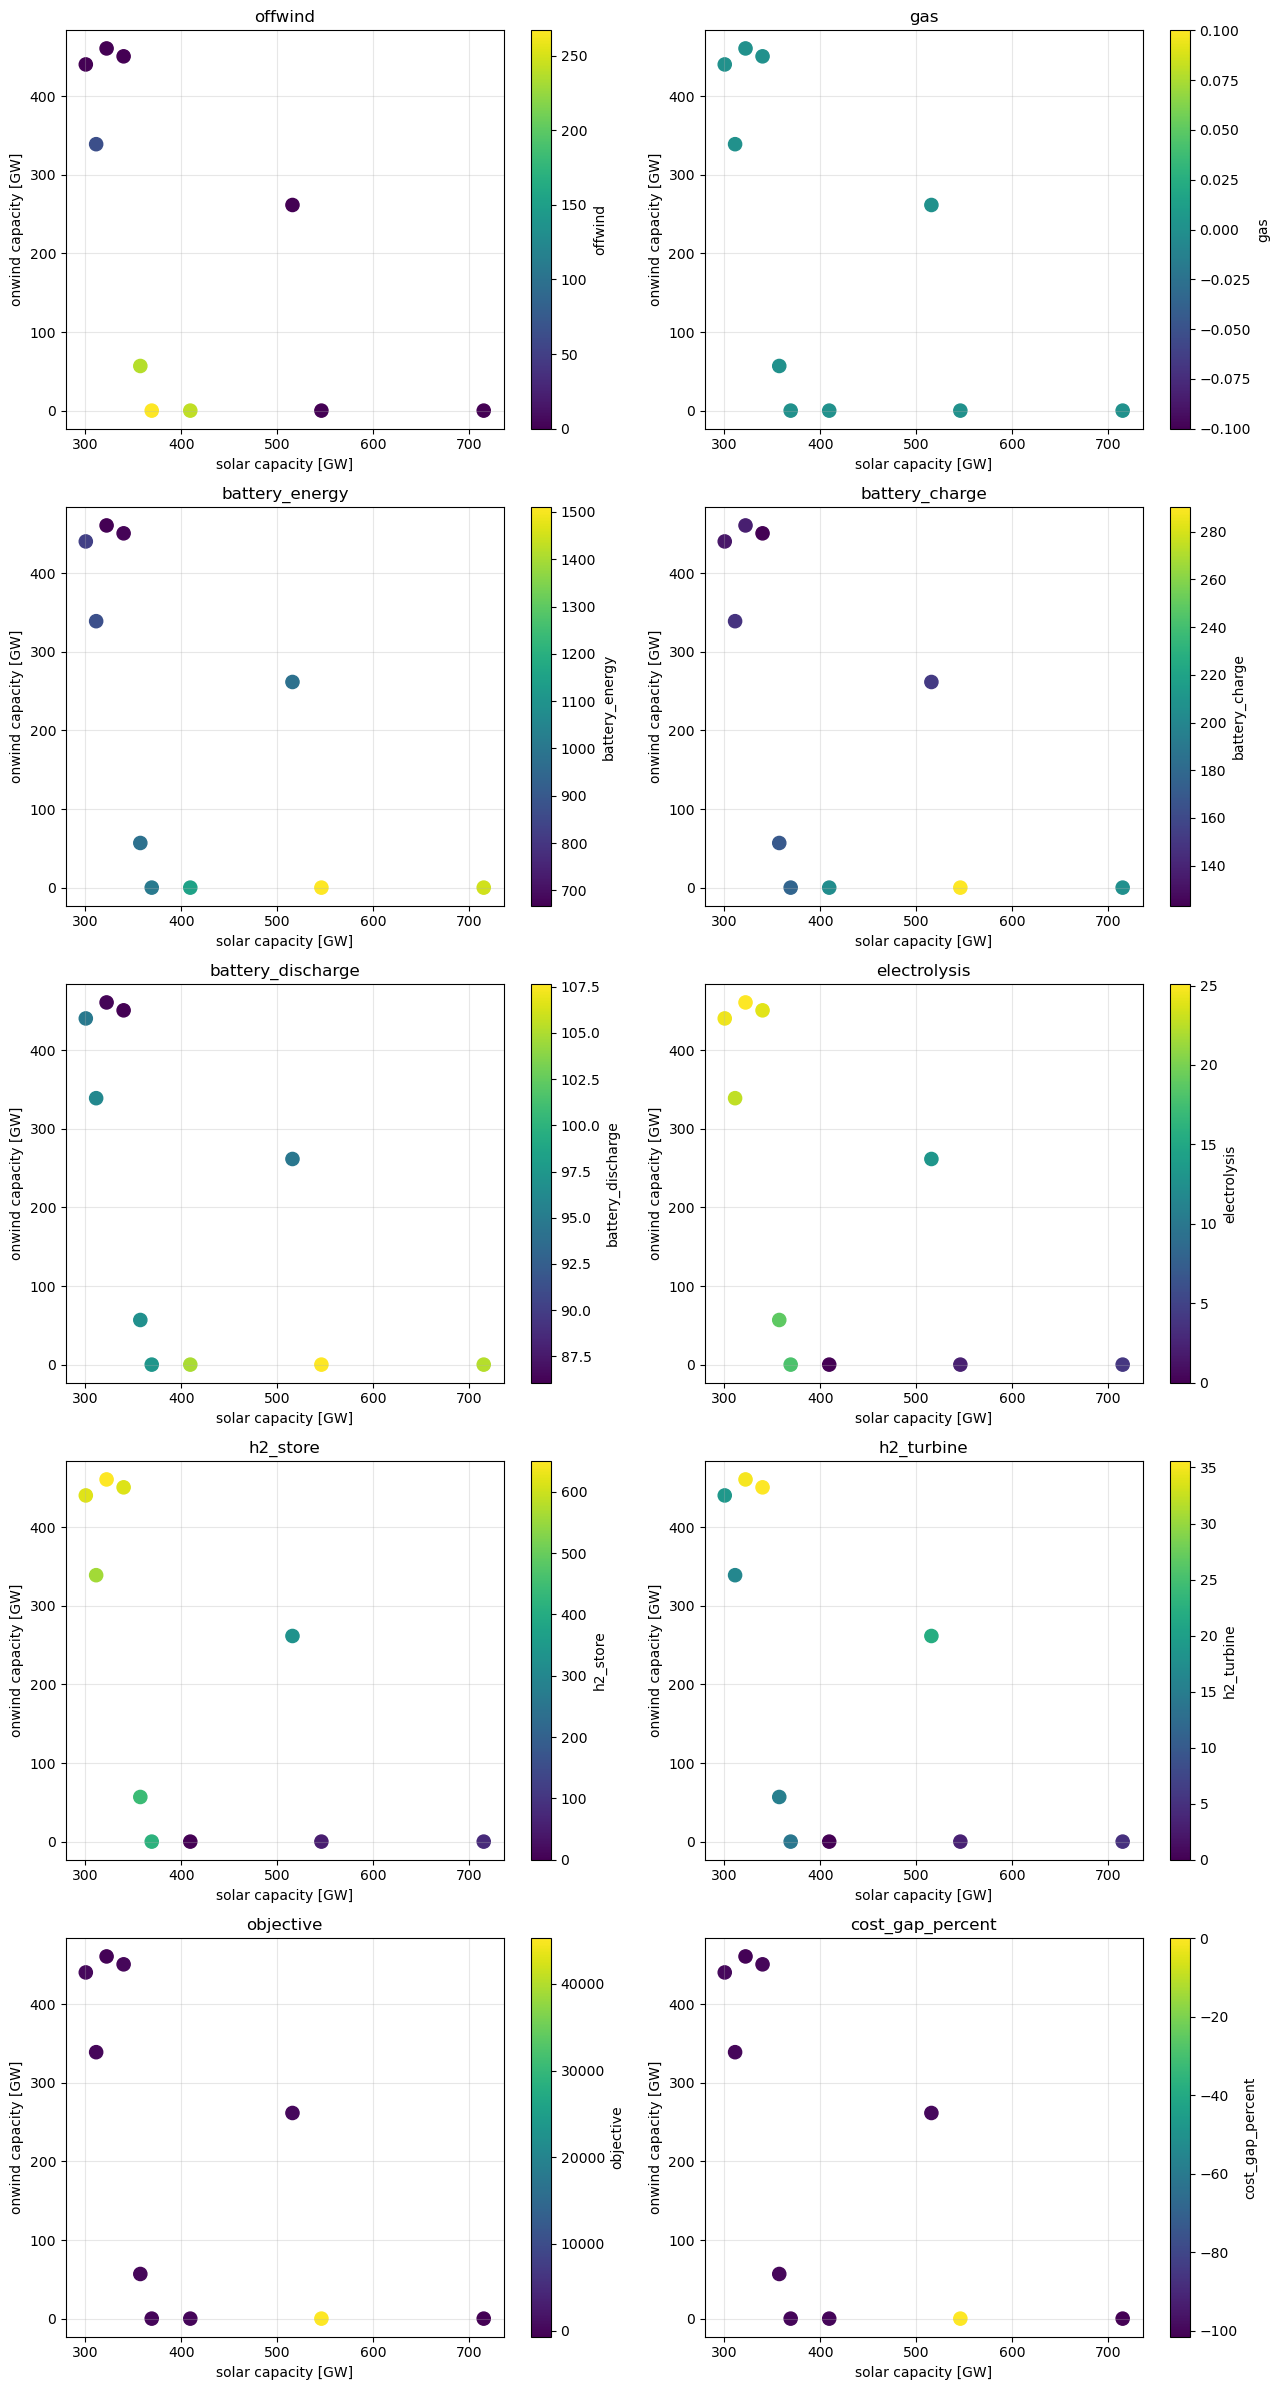

In [ ]:

plot_capacity_and_cost_maps(
    tech_df,
    result.z_names,
    path="/home/julian-geis/Documents/06_PhD/03RobustModelling/ORACLE/oracle_tech_cost_maps.png",
)

